### Import Library dan Load Dataset dari Kaggle

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "BIKE DETAILS.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "nehalbirla/motorcycle-dataset",
    file_path
)

df

/var/folders/r9/lcyjp3jn1klfnprvdq9zpy980000gn/T/ipykernel_26145/2477702759.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


### Import Library dan Load Dataset dari Kaggle

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   str    
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   str    
 4   owner              1061 non-null   str    
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), str(3)
memory usage: 97.0 KB


### Statistik Dataset

In [23]:
df.describe()

,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


### Pilih Kolom yang Digunakan

In [24]:
data = df[[
    'name',
    'selling_price',
    'year',
    'owner',
    'km_driven',
    'ex_showroom_price'
]].copy()

data

,name,selling_price,year,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,1st owner,350,NaN
1,Honda Dio,45000,2017,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000,NaN
...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,1st owner,53000,58000.0


### Hapus Data Kosong

In [25]:
data = data.dropna()
print("Jumlah data setelah dropna:", len(data))

Jumlah data setelah dropna: 626


### Konversi Owner Menjadi Skor

In [26]:
owner_mapping = {
    '1st owner': 5,
    '2nd owner': 4,
    '3rd owner': 3,
    '4th owner': 2,
    '4 or More Owners': 1,
    'Test Drive Car': 5
}

data['owner_score'] = data['owner'].map(owner_mapping).fillna(1)

data[['owner', 'owner_score']]

,owner,owner_score
2,1st owner,5
3,1st owner,5
5,1st owner,5
6,1st owner,5
9,1st owner,5
...,...,...
1056,1st owner,5
1057,1st owner,5
1058,2nd owner,4
1059,1st owner,5


### Pastikan Semua Kolom Numerik

In [27]:
numeric_cols = [
    'selling_price',
    'year',
    'km_driven',
    'ex_showroom_price',
    'owner_score'
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()

data

,name,selling_price,year,owner,km_driven,ex_showroom_price,owner_score
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,5
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,5
5,Honda CB Twister,18000,2010,1st owner,60000,53857.0,5
6,Honda CB Hornet 160R,78500,2018,1st owner,17000,87719.0,5
9,Bajaj Discover 125,50000,2016,1st owner,42000,60122.0,5
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,1st owner,500000,52000.0,5
1057,Honda CB twister,16000,2012,1st owner,33000,51000.0,5
1058,Bajaj Discover 125,15000,2013,2nd owner,35000,57000.0,4
1059,Honda CB Shine,12000,2009,1st owner,53000,58000.0,5


### Ambil 300 Data Pertama

In [28]:
data = data.head(300).reset_index(drop=True)

data

,name,selling_price,year,owner,km_driven,ex_showroom_price,owner_score
0,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,5
1,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,5
2,Honda CB Twister,18000,2010,1st owner,60000,53857.0,5
3,Honda CB Hornet 160R,78500,2018,1st owner,17000,87719.0,5
4,Bajaj Discover 125,50000,2016,1st owner,42000,60122.0,5
...,...,...,...,...,...,...,...
295,Bajaj V15,50000,2017,1st owner,9000,65626.0,5
296,Honda Activa [2000-2015],35000,2013,1st owner,29500,50267.0,5
297,Hero Maestro Edge,55000,2018,1st owner,39000,52790.0,5
298,Hero Glamour 125,40000,2016,1st owner,15000,61600.0,5


### Tentukan Bobot Kriteria

In [29]:
# [Harga, Tahun, Kilometer, Owner, Ex-Showroom]
weights = [5, 5, 5, 5, 5]

weights = np.array(weights, dtype=float)
weights = weights / weights.sum()

print("Bobot Normalisasi:")
print(weights)

Bobot Normalisasi:
[0.2 0.2 0.2 0.2 0.2]


### Ubah Bobot Cost Menjadi Negatif

In [30]:
adjusted_weights = np.array([
    -weights[0],  # selling_price (Cost)
     weights[1],  # year (Benefit)
    -weights[2],  # km_driven (Cost)
     weights[3],  # owner_score (Benefit)
     weights[4]   # ex_showroom_price (Benefit)
])

print("Bobot Setelah Penyesuaian:")
print(adjusted_weights)

Bobot Setelah Penyesuaian:
[-0.2  0.2 -0.2  0.2  0.2]


### Matriks Keputusan

In [31]:
X = data[[
    'selling_price',
    'year',
    'km_driven',
    'owner_score',
    'ex_showroom_price'
]].astype(float)

# Hindari nilai 0
X = X.replace(0, 1)

X

,selling_price,year,km_driven,owner_score,ex_showroom_price
0,150000.0,2018.0,12000.0,5.0,148114.0
1,65000.0,2015.0,23000.0,5.0,89643.0
2,18000.0,2010.0,60000.0,5.0,53857.0
3,78500.0,2018.0,17000.0,5.0,87719.0
4,50000.0,2016.0,42000.0,5.0,60122.0
...,...,...,...,...,...
295,50000.0,2017.0,9000.0,5.0,65626.0
296,35000.0,2013.0,29500.0,5.0,50267.0
297,55000.0,2018.0,39000.0,5.0,52790.0
298,40000.0,2016.0,15000.0,5.0,61600.0


### Hitung Vektor S

In [32]:
S = np.prod(np.power(X, adjusted_weights), axis=1)

print("10 Nilai S Pertama:")
print(S[:10])

10 Nilai S Pertama:
0    0.963481
1    0.904116
2    0.870957
3    0.921156
4    0.779929
5    0.933284
6    1.063575
7    0.894122
8    1.538890
9    0.843361
dtype: float64


### Hitung Vektor V

In [33]:
V = S / np.sum(S)

print("10 Nilai V Pertama:")
print(V[:10])

10 Nilai V Pertama:
0    0.003389
1    0.003181
2    0.003064
3    0.003241
4    0.002744
5    0.003283
6    0.003742
7    0.003145
8    0.005414
9    0.002967
dtype: float64


### Gabungkan Hasil

In [34]:
hasil = data.copy()
hasil['Skor WP'] = V

hasil.head(10)

,name,selling_price,year,owner,km_driven,ex_showroom_price,owner_score,Skor WP
0,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,5,0.003389
1,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,5,0.003181
2,Honda CB Twister,18000,2010,1st owner,60000,53857.0,5,0.003064
3,Honda CB Hornet 160R,78500,2018,1st owner,17000,87719.0,5,0.003241
4,Bajaj Discover 125,50000,2016,1st owner,42000,60122.0,5,0.002744
5,Yamaha FZ16,35000,2015,1st owner,32000,78712.0,5,0.003283
6,Honda Navi,28000,2016,2nd owner,10000,47255.0,4,0.003742
7,Bajaj Avenger Street 220,80000,2018,1st owner,21178,95955.0,5,0.003145
8,Yamaha YZF R3,365000,2019,1st owner,1127,351680.0,5,0.005414
9,Suzuki Access 125 [2007-2016],25000,2012,1st owner,55000,58314.0,5,0.002967


### Sorting Ranking

In [35]:
hasil = hasil.sort_values('Skor WP', ascending=False).reset_index(drop=True)
hasil['Peringkat'] = hasil.index + 1

hasil.head(10)

,name,selling_price,year,owner,km_driven,ex_showroom_price,owner_score,Skor WP,Peringkat
0,Royal Enfield Classic Gunmetal Grey,190000,2020,1st owner,500,155740.0,5,0.006167,1
1,Yamaha YZF R3,365000,2019,1st owner,1127,351680.0,5,0.005414,2
2,Mahindra Mojo XT300,165000,2017,1st owner,1933,195500.0,5,0.005064,3
3,Yamaha Fascino 110,69000,2019,1st owner,1600,57112.0,5,0.004896,4
4,BMW G310GS,300000,2018,1st owner,2500,349000.0,5,0.004793,5
5,Honda Activa 3G,40000,2015,1st owner,3000,54605.0,5,0.004770,6
6,Hero Glamour 125,55000,2017,1st owner,2500,61600.0,5,0.004756,7
7,Royal Enfield Thunderbird 350X,145000,2019,1st owner,2700,164004.0,5,0.004694,8
8,Vespa LX 125,50000,2015,1st owner,3909,77900.0,5,0.004645,9
9,Yamaha Fazer FI V 2.0 [2016-2018],65000,2018,1st owner,3500,89643.0,5,0.004636,10


### Tampilkan Ranking Akhir

In [36]:
ranking = hasil[[
    'Peringkat',
    'name',
    'selling_price',
    'year',
    'km_driven',
    'owner',
    'Skor WP'
]]

ranking.head(30)

,Peringkat,name,selling_price,year,km_driven,owner,Skor WP
0,1,Royal Enfield Classic Gunmetal Grey,190000,2020,500,1st owner,0.006167
1,2,Yamaha YZF R3,365000,2019,1127,1st owner,0.005414
2,3,Mahindra Mojo XT300,165000,2017,1933,1st owner,0.005064
3,4,Yamaha Fascino 110,69000,2019,1600,1st owner,0.004896
4,5,BMW G310GS,300000,2018,2500,1st owner,0.004793
5,6,Honda Activa 3G,40000,2015,3000,1st owner,0.004770
6,7,Hero Glamour 125,55000,2017,2500,1st owner,0.004756
7,8,Royal Enfield Thunderbird 350X,145000,2019,2700,1st owner,0.004694
8,9,Vespa LX 125,50000,2015,3909,1st owner,0.004645
9,10,Yamaha Fazer FI V 2.0 [2016-2018],65000,2018,3500,1st owner,0.004636


### Visualisasi 1: Distribusi Harga
Menunjukkan Berbagai harga jual motor bekas.

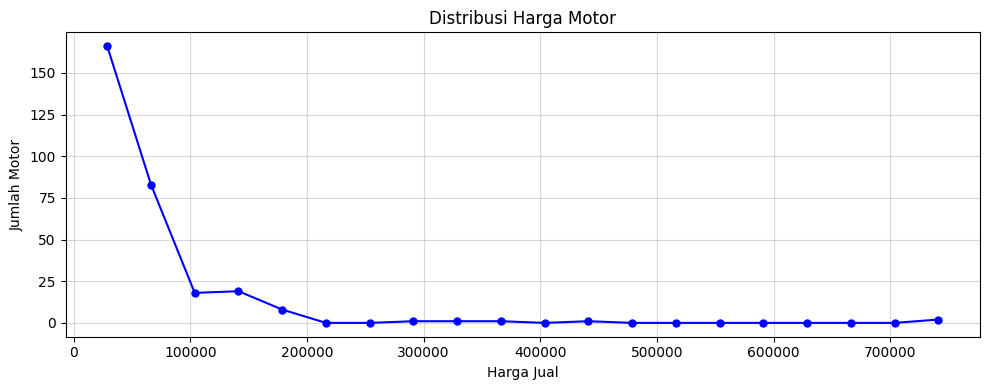

In [37]:
# Hitung jumlah data pada setiap rentang harga
jumlah, batas = np.histogram(data["selling_price"], bins=20)

# Titik tengah setiap rentang
x = (batas[:-1] + batas[1:]) / 2
y = jumlah

plt.figure(figsize=(10, 4))

plt.plot(
    x,
    y,
    marker="o",
    markersize=5,
    color="blue",
    linestyle="-"
)

plt.title("Distribusi Harga Motor")
plt.xlabel("Harga Jual")
plt.ylabel("Jumlah Motor")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Visuaslisasi 2 : Harga Berdasarkan Tahun
Menunjukkan hubungan tahun produksi dengan harga.

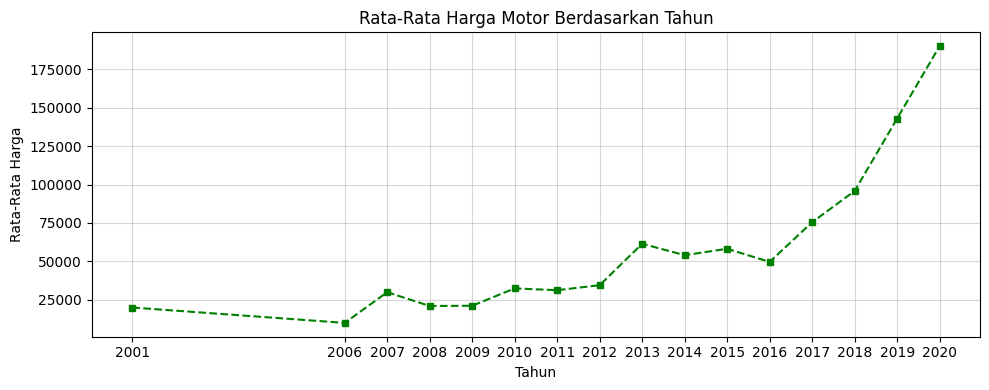

In [38]:
# Rata-rata harga berdasarkan tahun
tahun_harga = (
    data.groupby("year")["selling_price"]
    .mean()
    .reset_index()
    .sort_values("year")
)

# Sumbu X dan Y
x = tahun_harga["year"]
y = tahun_harga["selling_price"]

# Ukuran grafik
plt.figure(figsize=(10, 4))

# Grafik garis
plt.plot(
    x,
    y,
    marker="s",
    markersize=5,
    color="green",
    linestyle="--"
)

# Judul dan label
plt.title("Rata-Rata Harga Motor Berdasarkan Tahun")
plt.xlabel("Tahun")
plt.ylabel("Rata-Rata Harga")

# Menampilkan hanya tahun bulat
plt.xticks(x)

# Grid
plt.grid(True, alpha=0.5)

# Rapikan layout
plt.tight_layout()

# Tampilkan grafik
plt.show()

### Visualisasi 3 : Jumlah Motor Berdasarkan Tahun Produksi
Menunjukkan tahun produksi yang paling banyak Memproduksi Motor.

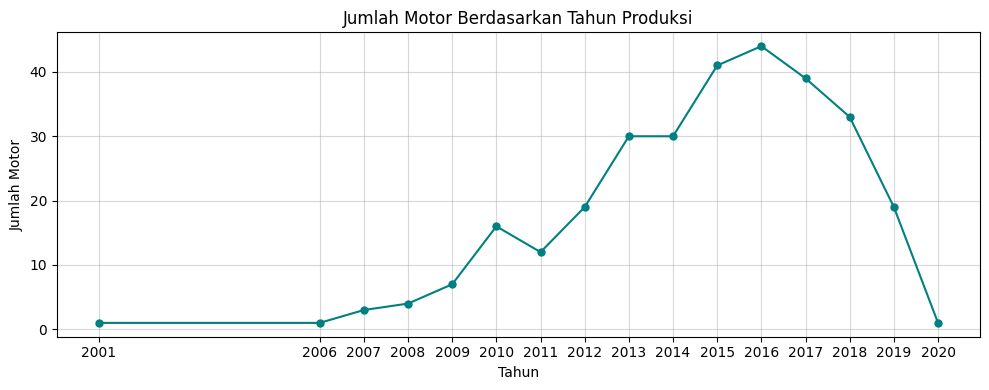

In [39]:
jumlah_tahun = (
    data["year"]
    .value_counts()
    .sort_index()
)

x = jumlah_tahun.index
y = jumlah_tahun.values

plt.figure(figsize=(10, 4))

plt.plot(
    x,
    y,
    marker="o",
    markersize=5,
    color="teal",
    linestyle="-"
)

plt.title("Jumlah Motor Berdasarkan Tahun Produksi")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Motor")

# Menampilkan hanya tahun bulat
plt.xticks(x)

plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Tampilkan Motor Terbaik

In [40]:
print('Motor Bekas Terbaik Berdasarkan Metode WP:')
ranking.head(1)

Motor Bekas Terbaik Berdasarkan Metode WP:


,Peringkat,name,selling_price,year,km_driven,owner,Skor WP
0,1,Royal Enfield Classic Gunmetal Grey,190000,2020,500,1st owner,0.006167
